# Predicting High Audience Ratings for Silver Screen Studios

Silver Screen Studios wants to know, before a film is made, whether it is likely to reach an IMDb audience rating of 8.0 or higher, using only information available in pre-production: genre, runtime, certificate, and the people attached. The goal is to help decide which projects get production funding. Anything only measurable after release cannot be an input, since it would not exist when the funding decision is made.

In [1]:
import pandas as pd

df = pd.read_csv("data/imdb_top_1000.csv")

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
df.head()

Shape: (1000, 16)

Dtypes:
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Column dictionary

| Column | Dtype as loaded | Description |
|---|---|---|
| Poster_Link | object | URL to the movie poster image on IMDb. |
| Series_Title | object | Title of the film. |
| Released_Year | object | Year the film was released. Loaded as text because at least one row contains a non-numeric value. |
| Certificate | object | Age certification the film received, such as A, UA, or PG-13. |
| Runtime | object | Length of the film as text, for example "142 min". |
| Genre | object | One or more genres as a comma-separated string, for example "Action, Crime, Drama". |
| IMDB_Rating | float64 | Average IMDb user rating on a 0 to 10 scale. This is the basis of the prediction target. |
| Overview | object | Short plot summary of the film. |
| Meta_score | float64 | Metacritic critic score on a 0 to 100 scale. |
| Director | object | Name of the film's director. |
| Star1 | object | First-billed cast member. |
| Star2 | object | Second-billed cast member. |
| Star3 | object | Third-billed cast member. |
| Star4 | object | Fourth-billed cast member. |
| No_of_Votes | int64 | Number of IMDb user votes behind the rating. |
| Gross | object | Box office gross in US dollars, loaded as text because the values contain commas. |

One difference from the proposal is worth noting. The proposal listed 10 columns and said cast was not in the dataset, but the file has 16, including Star1 through Star4, No_of_Votes, and Gross. Meta_score, No_of_Votes, and Gross are only known after release, so they are out as inputs. The cast columns are pre-production information, and the client has approved using them. My plan is to treat cast the same way as director, by turning the names into counts.

## Exploratory data analysis

### Data quality

Runtime is text like "142 min", so I stripped the suffix and made a numeric column, Runtime_Min; every row parsed cleanly, with runtimes from 45 to 321 minutes and a mean about 123.

In [2]:
df["Runtime_Min"] = df["Runtime"].str.replace(" min", "").astype(int)
print(df["Runtime_Min"].describe().round(1))

count    1000.0
mean      122.9
std        28.1
min        45.0
25%       103.0
50%       119.0
75%       137.0
max       321.0
Name: Runtime_Min, dtype: float64


Gross is text with commas, like "28,341,469". I removed the commas and converted to numbers. No new gaps appeared, but 169 films have no gross at all. I kept those rows, since Gross will not be a model input and filling the gaps did not seem worth it.

In [3]:
missing_before = df["Gross"].isna().sum()
df["Gross"] = pd.to_numeric(df["Gross"].str.replace(",", ""), errors="coerce")
print("Missing before conversion:", missing_before)
print("Missing after conversion: ", df["Gross"].isna().sum())

Missing before conversion: 169
Missing after conversion:  169


Released_Year loaded as text, which made me suspect a non-numeric value somewhere. Sure enough, there was one bad row. Apollo 13 has the value "PG", probably a data entry slip. The real year is easy to look up (1995), so I set it by hand and then converted the column to integers.

In [4]:
year_numeric = pd.to_numeric(df["Released_Year"], errors="coerce")
print(df.loc[year_numeric.isna(), ["Series_Title", "Released_Year", "Director"]])

df.loc[df["Series_Title"] == "Apollo 13", "Released_Year"] = 1995
df["Released_Year"] = df["Released_Year"].astype(int)
print("\nYear range:", df["Released_Year"].min(), "to", df["Released_Year"].max())

    Series_Title Released_Year    Director
966    Apollo 13            PG  Ron Howard

Year range: 1920 to 2020


Certificate is missing for 101 films and Meta_score for 157. I left both alone. Certificate can get its own "Missing" category when I build features, and Meta_score will not be an input anyway since it is post-release.

In [5]:
print("Missing Certificate:", df["Certificate"].isna().sum())
print("Missing Meta_score: ", df["Meta_score"].isna().sum())

Missing Certificate: 101
Missing Meta_score:  157


Each film lists one to three genres in one comma separated string, so I split the column to count them. There are 21 distinct genres. Drama appears on 724 of the 1000 films, then Comedy (233) and Crime (209). Films carry several genres, so the counts below sum to more than 1000. This column will need splitting into one column per genre before it can be a feature.

In [6]:
genre_counts = df["Genre"].str.split(", ").explode().value_counts()
print("Distinct genres:", genre_counts.size)
print(genre_counts)

Distinct genres: 21
Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64


### Distributions and relationships

The target is high_rated, True when IMDB_Rating is at least 8.0. The split is 463 high rated (46.3 percent) against 537 below (53.7 percent). Closer to balanced than I expected, so I don't think any rebalancing is needed. Accuracy alone still feels like a weak summary, so I plan to report precision and recall too.

In [7]:
df["high_rated"] = df["IMDB_Rating"] >= 8.0
counts = df["high_rated"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (100 * counts / len(df)).round(1)}))

            count  percent
high_rated                
False         537     53.7
True          463     46.3


The histogram below shows what I think is the most important fact about this dataset. Ratings start around 7.6, because this is the IMDb top 1000 and no poorly received film is in it. A model trained here can only learn to separate well received films from exceptionally well received ones. It cannot tell a hit from a flop, and scoring a typical unreleased project would be guessing outside anything it has seen.

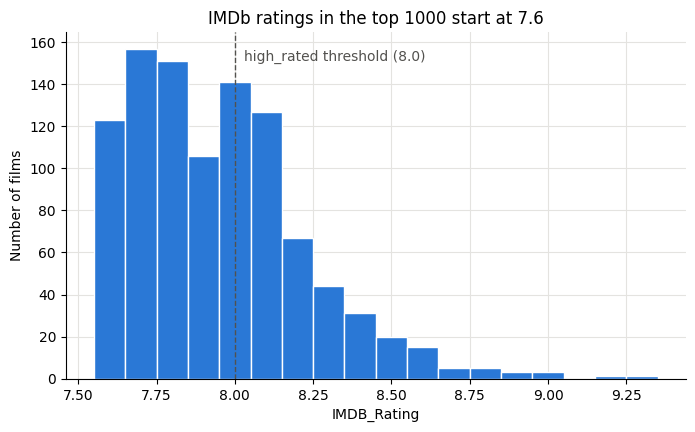

In [8]:
import numpy as np
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
INK = "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 100,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["IMDB_Rating"], bins=np.arange(7.55, 9.45, 0.1), color=BLUE, edgecolor="white")
ax.axvline(8.0, color=INK, linestyle="--", linewidth=1)
ax.text(8.03, ax.get_ylim()[1] * 0.95, "high_rated threshold (8.0)", color=INK, va="top")
ax.set_title("IMDb ratings in the top 1000 start at 7.6")
ax.set_xlabel("IMDB_Rating")
ax.set_ylabel("Number of films")
plt.show()

Rating against runtime shows a weak positive relationship (correlation about 0.24), with longer films rating slightly higher. The spread at any runtime is wide, though, so runtime seems to carry some signal but not much on its own.

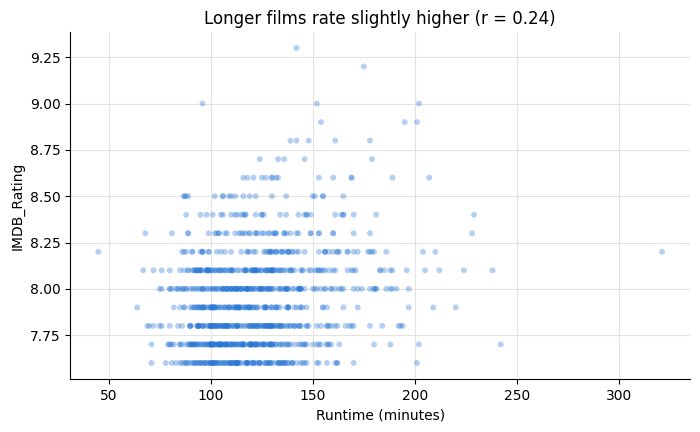

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df["Runtime_Min"], df["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_title(f"Longer films rate slightly higher (r = {df['Runtime_Min'].corr(df['IMDB_Rating']):.2f})")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("IMDB_Rating")
plt.show()

The next chart shows mean rating per release decade. The line stays within roughly 7.9 to 8.1 across a century, basically flat. Earlier decades sit a bit higher, which I suspect is survivorship, since only the best remembered old films make a top 1000 list. The endpoints rest on few films (11 from the 1920s, 6 from the 2020s), so I don't put much weight on them.

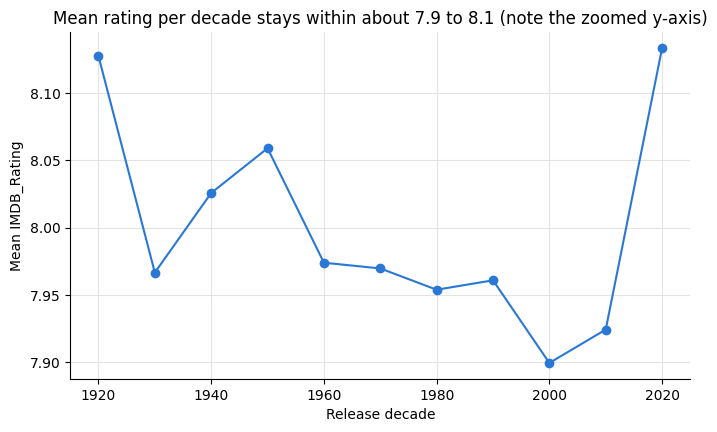

In [10]:
decade_stats = df.groupby(df["Released_Year"] // 10 * 10)["IMDB_Rating"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decade_stats.index, decade_stats["mean"], marker="o", color=BLUE)
ax.set_title("Mean rating per decade stays within about 7.9 to 8.1 (note the zoomed y-axis)")
ax.set_xlabel("Release decade")
ax.set_ylabel("Mean IMDB_Rating")
plt.show()

For genre, I split the labels apart and computed each genre's mean rating and film count. The spread is narrow, about 7.89 for Horror to 8.01 for War, and the group sizes differ wildly (Drama 724 films, Film-Noir 19). Genre barely moves the average, so on its own it does not look helpful, though it might combine well with other features.

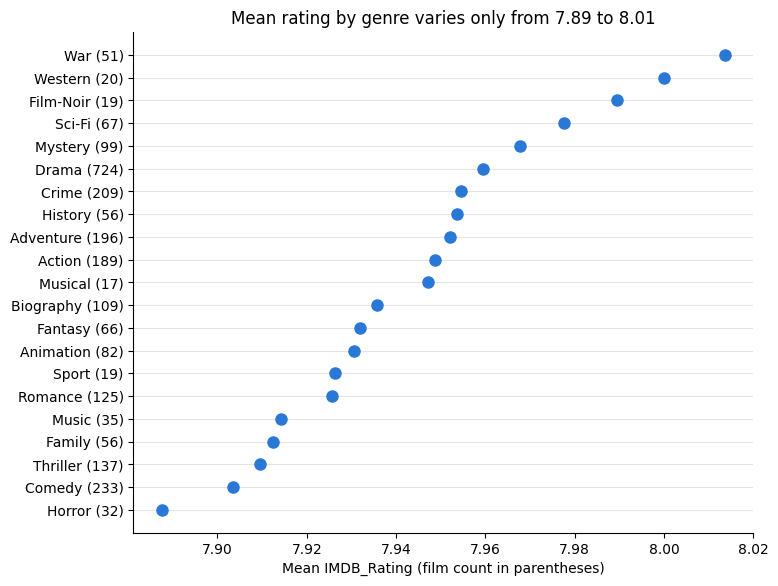

In [11]:
genre_stats = (df.assign(Genre=df["Genre"].str.split(", ")).explode("Genre")
               .groupby("Genre")["IMDB_Rating"].agg(["mean", "count"])
               .sort_values("mean"))
labels = [f"{g} ({c})" for g, c in zip(genre_stats.index, genre_stats["count"])]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.plot(genre_stats["mean"], range(len(genre_stats)), "o", color=BLUE, markersize=8)
ax.set_yticks(range(len(genre_stats)), labels)
ax.grid(axis="x")
ax.set_title("Mean rating by genre varies only from 7.89 to 8.01")
ax.set_xlabel("Mean IMDB_Rating (film count in parentheses)")
plt.show()

Certificate gets the same view, for certificates with at least 10 films. Rarer ones and the 101 missing values are left out of the chart but stay in the data. Differences are again small, about 7.80 for PG-13 up to 8.02 for Passed, another weak signal on its own.

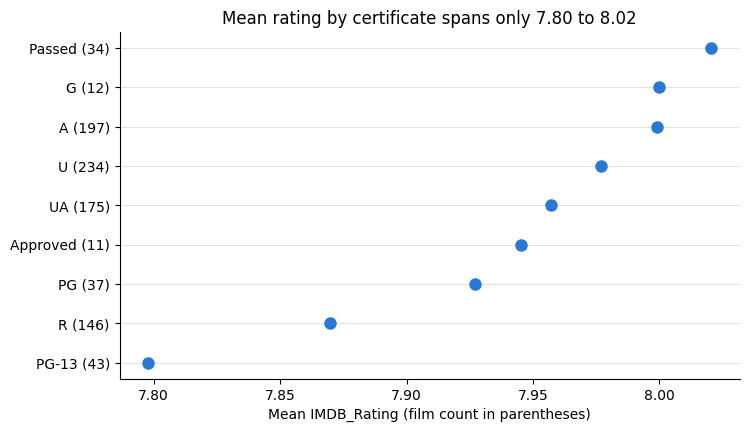

In [12]:
cert_stats = (df.groupby("Certificate")["IMDB_Rating"].agg(["mean", "count"])
              .query("count >= 10").sort_values("mean"))
labels = [f"{c} ({n})" for c, n in zip(cert_stats.index, cert_stats["count"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cert_stats["mean"], range(len(cert_stats)), "o", color=BLUE, markersize=8)
ax.set_yticks(range(len(cert_stats)), labels)
ax.grid(axis="x")
ax.set_title("Mean rating by certificate spans only 7.80 to 8.02")
ax.set_xlabel("Mean IMDB_Rating (film count in parentheses)")
plt.show()

The 1000 films come from 548 directors. 352 appear exactly once, 196 more than once, and Alfred Hitchcock leads with 14. Giving each director their own column would create hundreds of columns that each match one film, a recipe for overfitting. If I use director at all, it should be boiled down, maybe a repeat-director flag or a film count.

Distinct directors: 548
Appear once:        352
Appear 2+ times:    196


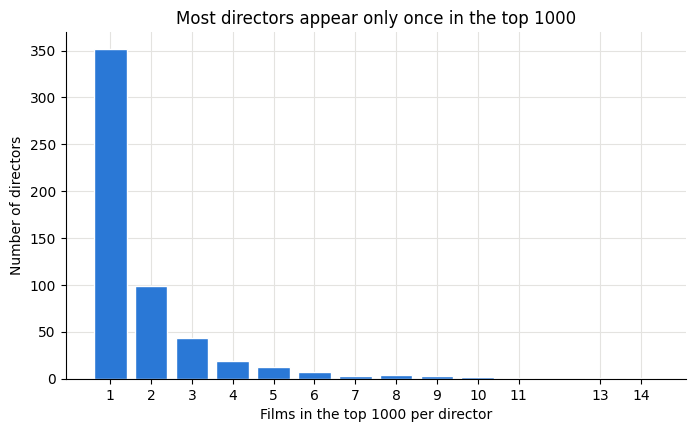

In [13]:
films_per_director = df["Director"].value_counts()
print("Distinct directors:", films_per_director.size)
print("Appear once:       ", (films_per_director == 1).sum())
print("Appear 2+ times:   ", (films_per_director > 1).sum())

dist = films_per_director.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(dist.index, dist.values, color=BLUE, edgecolor="white")
ax.set_xticks(dist.index)
ax.set_title("Most directors appear only once in the top 1000")
ax.set_xlabel("Films in the top 1000 per director")
ax.set_ylabel("Number of directors")
plt.show()

The last two charts are context for the client. Gross, No_of_Votes, and Meta_score are post-release and stay excluded as features. First, rating against box office gross on a log scale, for the 831 films with a gross figure. The correlation between rating and log gross is essentially zero, which surprised me. In this top tier, how highly audiences rate a film says almost nothing about how much it earns, so a high predicted rating is not a revenue forecast.

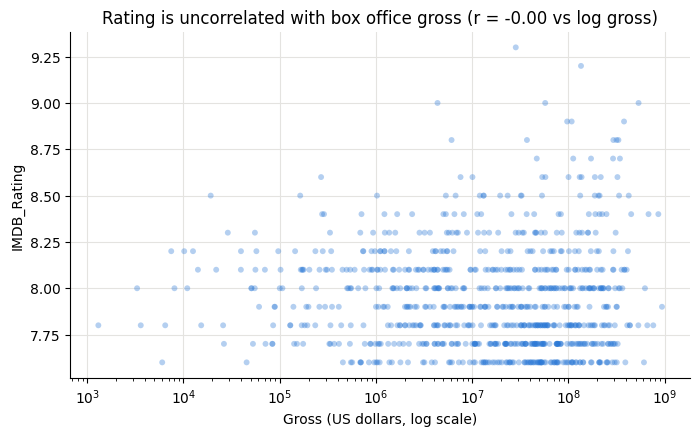

In [14]:
has_gross = df.dropna(subset=["Gross"])
r = np.corrcoef(np.log10(has_gross["Gross"]), has_gross["IMDB_Rating"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(has_gross["Gross"], has_gross["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log")
ax.set_title(f"Rating is uncorrelated with box office gross (r = {r:.2f} vs log gross)")
ax.set_xlabel("Gross (US dollars, log scale)")
ax.set_ylabel("IMDB_Rating")
plt.show()

The second chart plots rating against vote count, also on a log scale. This one is moderately positive (correlation about 0.33 with log votes), so films with more votes tend to rate somewhat higher. I suspect a popularity feedback effect, where widely seen films attract both votes and enthusiasm, so I would not read it as pure quality either.

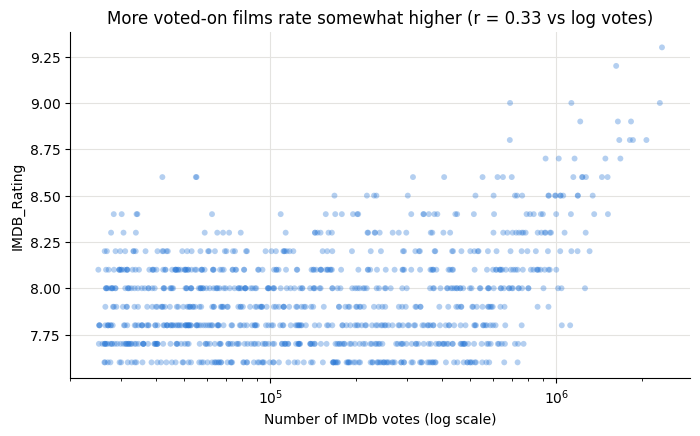

In [15]:
r = np.corrcoef(np.log10(df["No_of_Votes"]), df["IMDB_Rating"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df["No_of_Votes"], df["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log")
ax.set_title(f"More voted-on films rate somewhat higher (r = {r:.2f} vs log votes)")
ax.set_xlabel("Number of IMDb votes (log scale)")
ax.set_ylabel("IMDB_Rating")
plt.show()

## EDA summary

The data needed only light cleaning. Runtime and Gross became numbers, one Released_Year typo (Apollo 13) was fixed by hand, and no rows were dropped. Missing values sit in Gross (169), Meta_score (157), and Certificate (101), none of which blocks modeling. The target split of 46 to 54 is close to balanced. What stands out most is selection. Every film here is already among IMDb's best, ratings 7.6 and up, so a model can only learn what separates good from exceptional, not hits from flops. Within that band the signals look individually weak. Runtime correlates mildly with rating, genre and certificate move the mean by about a tenth of a point, and director is mostly one-off names. Rating is essentially uncorrelated with gross here, so commercial success is no shortcut. Going into modeling I expect modest performance, and I will read the model as ranking projects within an already strong field.

## Class comparisons

The client suggested comparing the two classes directly, which makes sense for a yes or no problem. I compare high rated films against the rest on runtime, decade, and genre.

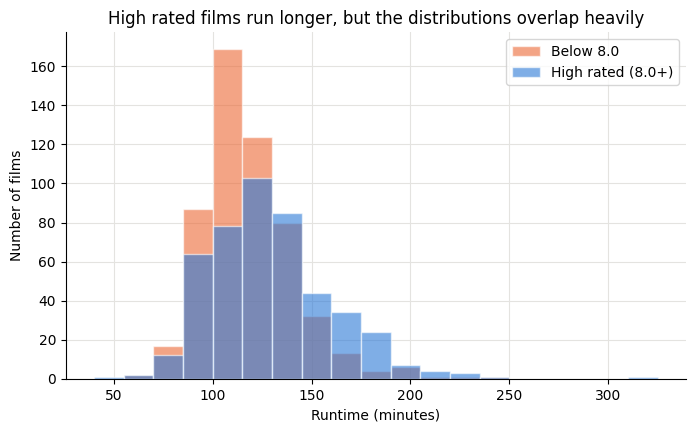

            median   mean
high_rated               
False        114.0  117.6
True         125.0  129.0


In [16]:
ORANGE = "#eb6834"
bins = np.arange(40, 335, 15)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df.loc[~df["high_rated"], "Runtime_Min"], bins=bins, alpha=0.6,
        color=ORANGE, edgecolor="white", label="Below 8.0")
ax.hist(df.loc[df["high_rated"], "Runtime_Min"], bins=bins, alpha=0.6,
        color=BLUE, edgecolor="white", label="High rated (8.0+)")
ax.legend()
ax.set_title("High rated films run longer, but the distributions overlap heavily")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Number of films")
plt.show()
print(df.groupby("high_rated")["Runtime_Min"].agg(["median", "mean"]).round(1))

The two runtime distributions overlap a lot, but not completely. High rated films run longer, median 125 minutes against 114, mean 129 against 118, and they own most of the tail past three hours. Runtime shifts the odds a bit, so I expect it to help mostly in combination.

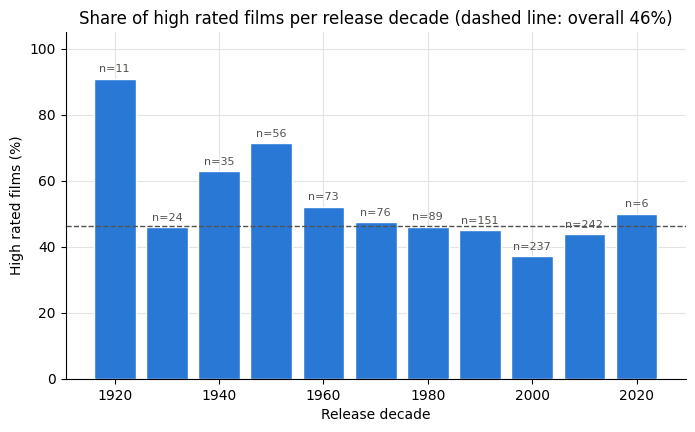

In [17]:
decade_share = df.groupby(df["Released_Year"] // 10 * 10)["high_rated"].agg(["mean", "count"])
overall = df["high_rated"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(decade_share.index, decade_share["mean"] * 100, width=8, color=BLUE, edgecolor="white")
ax.axhline(overall, color=INK, linestyle="--", linewidth=1)
for dec, row in decade_share.iterrows():
    ax.text(dec, row["mean"] * 100 + 2, f"n={row['count']:.0f}", ha="center", color=INK, fontsize=8)
ax.set_ylim(0, 105)
ax.set_title(f"Share of high rated films per release decade (dashed line: overall {overall:.0f}%)")
ax.set_xlabel("Release decade")
ax.set_ylabel("High rated films (%)")
plt.show()

The 1920s, 1940s, and 1950s sit well above the overall 46 percent share, at 91, 63, and 71 percent, but the 1930s sit at 46, so the early pattern is not even consistent. Those decades rest on few films (11, 35, and 56), so I don't trust their shares. From 1960 onward, where most of the data lives, shares stay between about 37 and 52 percent, with the 2000s lowest at 37. I think this is survivorship again.

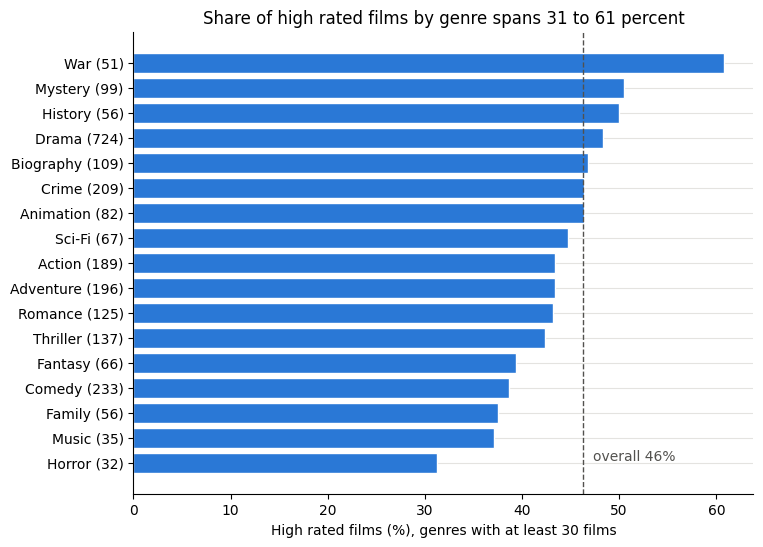

In [18]:
genre_share = (df.assign(Genre=df["Genre"].str.split(", ")).explode("Genre")
               .groupby("Genre")["high_rated"].agg(["mean", "count"])
               .query("count >= 30").sort_values("mean"))
labels = [f"{g} ({c})" for g, c in zip(genre_share.index, genre_share["count"])]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(genre_share)), genre_share["mean"] * 100, color=BLUE, edgecolor="white")
ax.axvline(overall, color=INK, linestyle="--", linewidth=1)
ax.text(overall + 1, 0.1, f"overall {overall:.0f}%", color=INK)
ax.set_yticks(range(len(genre_share)), labels)
ax.grid(axis="x")
ax.set_title("Share of high rated films by genre spans 31 to 61 percent")
ax.set_xlabel("High rated films (%), genres with at least 30 films")
plt.show()

I left genres with fewer than 30 films out of the chart (Western, Film-Noir, Sport, and Musical), since a share built on so few films is not readable. Among the rest, the share of high rated films runs from 31 percent for Horror to 61 percent for War. Comedy, Family, and Music skew low. Mystery, History, and Drama sit at or above the overall 46 percent. That 30 point spread is much wider than the flat mean ratings from earlier, which surprised me. Genre looks more promising than I thought.

To summarize, looking through the 8.0 threshold sharpened the picture more than I expected. High rated films run about ten minutes longer, and genre shares differ by up to 30 points. Decade mostly repeats the survivorship effect and adds little from 1960 onward.

## Modeling: predicting high rated films

The client asks whether a film will reach an IMDb rating of 8.0 or higher, and every row carries that outcome. That is supervised classification with a yes or no target. The client also told me missing a likely hit is worse than backing an underperformer, so I will judge models mostly on recall for the high rated class, meaning how many of the real hits they catch.

The inputs are the pre-production columns: Runtime_Min, Genre, Certificate, Released_Year as a decade, Director, and Star1 through Star4. The cell below puts the in and out lists on record.

In [19]:
input_columns = ["Runtime_Min", "Genre", "Certificate", "Released_Year",
                 "Director", "Star1", "Star2", "Star3", "Star4"]

excluded = {
    "Meta_score":   "post-release, not known in pre-production",
    "No_of_Votes":  "post-release, not known in pre-production",
    "Gross":        "post-release, not known in pre-production",
    "IMDB_Rating":  "source of the target, would leak the answer",
    "Series_Title": "identifier, not a property a new film shares",
    "Poster_Link":  "identifier and artwork link, out of scope",
    "Overview":     "raw text, out of scope for this project",
}

print("IN: ", input_columns)
for col, why in excluded.items():
    print(f"OUT {col}: {why}")

IN:  ['Runtime_Min', 'Genre', 'Certificate', 'Released_Year', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']
OUT Meta_score: post-release, not known in pre-production
OUT No_of_Votes: post-release, not known in pre-production
OUT Gross: post-release, not known in pre-production
OUT IMDB_Rating: source of the target, would leak the answer
OUT Series_Title: identifier, not a property a new film shares
OUT Poster_Link: identifier and artwork link, out of scope
OUT Overview: raw text, out of scope for this project


The director and cast features are counts computed from other films in the data. If I computed them before splitting, test films would leak into the training features, a risk the client flagged too. So the split comes first, 80/20 on high_rated, stratified so both parts keep the same class mix, with a fixed random_state so the run repeats.

In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["high_rated"], random_state=42)

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Train high rated share:", round(train_df["high_rated"].mean(), 3))
print("Test high rated share: ", round(test_df["high_rated"].mean(), 3))

Train: (800, 18) | Test: (200, 18)
Train high rated share: 0.462
Test high rated share:  0.465


Genre becomes one column per genre, with the genre list learned from the training set only. As it turns out, all 21 genres show up in training, so nothing is lost.

In [21]:
genre_categories = sorted(train_df["Genre"].str.split(", ").explode().unique())

def genre_multi_hot(frame):
    lists = frame["Genre"].str.split(", ")
    return pd.DataFrame({f"genre_{g}": lists.apply(lambda gs: int(g in gs))
                         for g in genre_categories}, index=frame.index)

genre_train = genre_multi_hot(train_df)
genre_test = genre_multi_hot(test_df)
print(len(genre_categories), "genre columns from training:", genre_categories)

21 genre columns from training: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']


Missing certificates get their own Missing category, since absence might mean something. Certificates with fewer than 20 training films get grouped into Other, because a rate estimated from a handful of rows is not worth much. Then one column per category, with the list learned from training so both splits match.

In [22]:
cert_counts = train_df["Certificate"].fillna("Missing").value_counts()
kept_certs = cert_counts[cert_counts >= 20].index.tolist()
cert_columns = [f"cert_{c}" for c in kept_certs + ["Other"]]

def certificate_one_hot(frame):
    cert = frame["Certificate"].fillna("Missing")
    cert = cert.where(cert.isin(kept_certs), "Other")
    return pd.get_dummies(cert, prefix="cert").reindex(columns=cert_columns, fill_value=0).astype(int)

cert_train = certificate_one_hot(train_df)
cert_test = certificate_one_hot(test_df)
print("Kept categories:", kept_certs)
print("Grouped into Other:", cert_counts[cert_counts < 20].index.tolist())

Kept categories: ['U', 'A', 'UA', 'R', 'Missing', 'PG-13', 'PG', 'Passed']
Grouped into Other: ['Approved', 'G', 'TV-PG', 'GP', 'TV-14', '16', 'U/A', 'TV-MA', 'Unrated']


Released_Year gets floored to its decade, one numeric column, since the EDA found year adds little but the mild decade pattern might still contribute.

In [23]:
decade_train = pd.DataFrame({"decade": train_df["Released_Year"] // 10 * 10}, index=train_df.index)
decade_test = pd.DataFrame({"decade": test_df["Released_Year"] // 10 * 10}, index=test_df.index)
print(decade_train["decade"].value_counts().sort_index())

decade
1920     10
1930     17
1940     30
1950     44
1960     61
1970     60
1980     73
1990    112
2000    188
2010    202
2020      3
Name: count, dtype: int64


director_film_count is how many other films by the same director are in the training set. For training rows I subtract the film's own appearance, otherwise the feature would partly describe the film itself. Test rows are not in the counts, so no subtraction, and an unseen director gets 0. is_repeat_director flags a count of at least 1.

In [24]:
director_counts = train_df["Director"].value_counts()

def director_features(frame, in_train):
    counts = frame["Director"].map(director_counts).fillna(0).astype(int)
    if in_train:
        counts = counts - 1
    return pd.DataFrame({"director_film_count": counts,
                         "is_repeat_director": (counts >= 1).astype(int)}, index=frame.index)

director_train = director_features(train_df, in_train=True)
director_test = director_features(test_df, in_train=False)
print("Train films whose director appears elsewhere in training:",
      int(director_train["is_repeat_director"].sum()), "of", len(train_df))
print("Test films with a director unseen in training:",
      int((director_test["director_film_count"] == 0).sum()), "of", len(test_df))

Train films whose director appears elsewhere in training: 488 of 800
Test films with a director unseen in training: 77 of 200


The same idea for the four billed stars. I count each star's appearances across Star1 through Star4 in training rows, again leaving out each film's own row. Each film then gets n_known_stars, how many of its four stars appear elsewhere in training, and max_star_count, the count of its most seen star. Unseen stars get 0. This keeps cast as a track record signal, which is what the client approved.

In [25]:
star_cols = ["Star1", "Star2", "Star3", "Star4"]
star_counts = pd.concat([train_df[c] for c in star_cols]).value_counts()

def cast_features(frame, in_train):
    per_star = pd.DataFrame({c: frame[c].map(star_counts).fillna(0).astype(int)
                             for c in star_cols}, index=frame.index)
    if in_train:
        per_star = (per_star - 1).clip(lower=0)
    return pd.DataFrame({"n_known_stars": (per_star >= 1).sum(axis=1),
                         "max_star_count": per_star.max(axis=1)}, index=frame.index)

cast_train = cast_features(train_df, in_train=True)
cast_test = cast_features(test_df, in_train=False)
print("Train n_known_stars distribution:")
print(cast_train["n_known_stars"].value_counts().sort_index())

Train n_known_stars distribution:
n_known_stars
0    157
1    196
2    239
3    138
4     70
Name: count, dtype: int64


Now everything gets stacked into the final matrices, with the shapes and feature list printed as a check.

In [26]:
def assemble(frame, genre, cert, decade, director, cast):
    return pd.concat([frame[["Runtime_Min"]], decade, genre, cert, director, cast], axis=1)

X_train = assemble(train_df, genre_train, cert_train, decade_train, director_train, cast_train)
X_test = assemble(test_df, genre_test, cert_test, decade_test, director_test, cast_test)
y_train = train_df["high_rated"]
y_test = test_df["high_rated"]

assert list(X_train.columns) == list(X_test.columns)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Features:", X_train.columns.tolist())

X_train: (800, 36) | X_test: (200, 36)
Features: ['Runtime_Min', 'decade', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Film-Noir', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Sport', 'genre_Thriller', 'genre_War', 'genre_Western', 'cert_U', 'cert_A', 'cert_UA', 'cert_R', 'cert_Missing', 'cert_PG-13', 'cert_PG', 'cert_Passed', 'cert_Other', 'director_film_count', 'is_repeat_director', 'n_known_stars', 'max_star_count']


The matrices are built with no test information inside any feature, so the next step is a first model, judged mainly on recall for the high rated class.

For a baseline I want something simple and readable, and logistic regression fits. It's one coefficient per feature, fast, and it outputs probabilities I can threshold later. The scaler is fit on training data only. I scale just the real-valued columns (Runtime_Min, decade, director_film_count, max_star_count) and leave the 0/1 columns alone.

Logistic regression: precision 0.652 | recall 0.462 | F1 0.541 | ROC-AUC 0.652


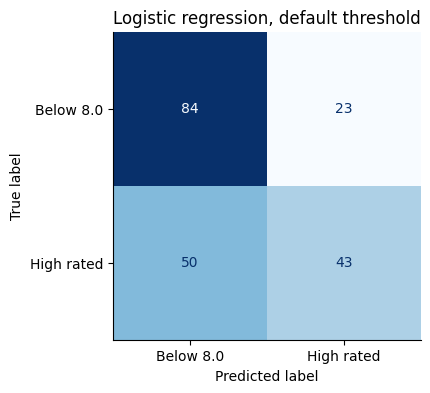

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

scale_cols = ["Runtime_Min", "decade", "director_film_count", "max_star_count"]
scaler = StandardScaler().fit(X_train[scale_cols])
X_train_lr = X_train.copy(); X_train_lr[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_lr = X_test.copy();  X_test_lr[scale_cols] = scaler.transform(X_test[scale_cols])

def evaluate(name, model, X):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    print(f"{name}: precision {precision_score(y_test, pred):.3f} | recall {recall_score(y_test, pred):.3f}"
          f" | F1 {f1_score(y_test, pred):.3f} | ROC-AUC {roc_auc_score(y_test, proba):.3f}")
    return pred, proba

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_lr, y_train)
lr_pred, lr_proba = evaluate("Logistic regression", logreg, X_test_lr)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=["Below 8.0", "High rated"],
                                        cmap="Blues", ax=ax, colorbar=False)
ax.grid(False)
ax.set_title("Logistic regression, default threshold")
plt.show()

On the test set the baseline gets precision 0.652, recall 0.462, F1 0.541, and ROC-AUC 0.652 for the high rated class. The confusion matrix shows the problem, with 50 of the 93 high rated test films missed at the default threshold. Precision is decent and recall is poor, the wrong way around for the client. The AUC of 0.652 says there is real signal, but modest, about what the EDA led me to expect.

The comparison model is a random forest, which can catch interactions a linear model misses, say runtime mattering differently by genre. I keep default settings apart from n_estimators=300 for stability and a fixed random_state. Trees don't care about scaling, so it gets the unscaled matrices.

Random forest: precision 0.614 | recall 0.462 | F1 0.528 | ROC-AUC 0.628


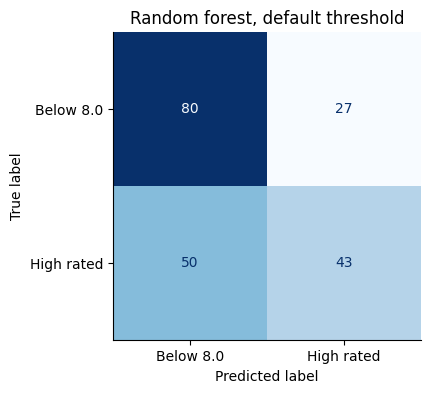

In [28]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
rf_pred, rf_proba = evaluate("Random forest", forest, X_test)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Below 8.0", "High rated"],
                                        cmap="Blues", ax=ax, colorbar=False)
ax.grid(False)
ax.set_title("Random forest, default threshold")
plt.show()

The forest lands at precision 0.614, recall 0.462, F1 0.528, ROC-AUC 0.628. On recall the two models tie at 0.462, each catching 43 of the 93 hits. Logistic regression is slightly ahead on AUC and precision, so the forest's extra flexibility buys nothing here. With signals this weak, I suspect there are no strong interactions to find.

The client's costs point at recall, so the first thing to try is class_weight="balanced", which makes the model care proportionally more about the smaller class. The classes are only mildly uneven, so I don't expect much, but it is the cheapest experiment.

In [29]:
logreg_bal = LogisticRegression(max_iter=1000, random_state=42,
                                class_weight="balanced").fit(X_train_lr, y_train)
evaluate("Logistic regression, balanced", logreg_bal, X_test_lr)

forest_bal = RandomForestClassifier(n_estimators=300, random_state=42,
                                    class_weight="balanced").fit(X_train, y_train)
evaluate("Random forest, balanced", forest_bal, X_test)

Logistic regression, balanced: precision 0.605 | recall 0.559 | F1 0.581 | ROC-AUC 0.652
Random forest, balanced: precision 0.592 | recall 0.452 | F1 0.512 | ROC-AUC 0.620


(array([False, False, False,  True, False,  True,  True, False, False,
         True, False, False, False, False,  True, False, False, False,
         True, False, False, False, False, False,  True,  True, False,
        False, False, False, False,  True,  True, False,  True, False,
        False, False, False,  True,  True, False, False,  True,  True,
        False, False,  True, False, False, False, False,  True, False,
         True,  True,  True, False,  True, False,  True, False, False,
         True,  True, False, False, False, False, False, False, False,
         True,  True, False, False, False,  True,  True, False, False,
         True, False, False,  True, False,  True, False, False, False,
         True, False,  True, False,  True,  True,  True, False,  True,
        False,  True,  True, False, False, False, False, False,  True,
        False,  True, False, False, False, False, False, False, False,
        False, False, False,  True,  True,  True, False,  True, False,
      

Balancing helps the logistic model, recall 0.462 up to 0.559 while precision slips from 0.652 to 0.605. It does nothing for the forest, whose recall dips to 0.452. So logistic regression is the better base for pushing recall. Weighting and thresholding are two versions of the same trade, so for the sweep I use the plain model's probabilities and keep one lever.

The second lever is the threshold itself. The default 0.5 cutoff is arbitrary, and lowering it flags more films as likely hits, trading precision for recall, the direction the client wants. I sweep 0.30 to 0.70 in steps of 0.05 and include the raw counts so the trade is concrete.

 threshold  precision  recall  hits_caught  false_positives
      0.30      0.503   0.871           81               80
      0.35      0.521   0.806           75               69
      0.40      0.543   0.677           63               53
      0.45      0.561   0.591           55               43
      0.50      0.652   0.462           43               23
      0.55      0.648   0.376           35               19
      0.60      0.683   0.301           28               13
      0.65      0.714   0.215           20                8
      0.70      0.750   0.129           12                4


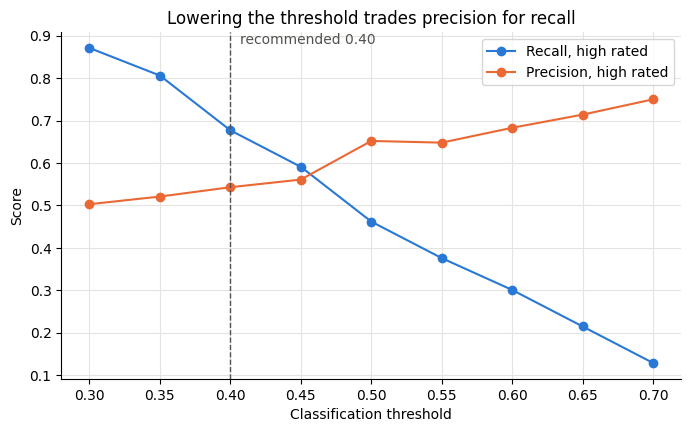

In [30]:
rows = []
for t in np.arange(0.30, 0.71, 0.05):
    pred = (lr_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({"threshold": round(t, 2),
                 "precision": precision_score(y_test, pred),
                 "recall": recall_score(y_test, pred),
                 "hits_caught": tp, "false_positives": fp})
sweep = pd.DataFrame(rows).round(3)
print(sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["threshold"], sweep["recall"], marker="o", color=BLUE, label="Recall, high rated")
ax.plot(sweep["threshold"], sweep["precision"], marker="o", color=ORANGE, label="Precision, high rated")
ax.axvline(0.40, color=INK, linestyle="--", linewidth=1)
ax.text(0.407, 0.88, "recommended 0.40", color=INK)
ax.legend()
ax.set_title("Lowering the threshold trades precision for recall")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
plt.show()

The client's preference says go lower, and 0.40 looks like the sensible spot. Against the default 0.50 it catches 20 more likely hits (63 of 93 instead of 43) at the cost of backing 30 more films that fall short (53 false positives instead of 23). Going to 0.35 catches 75 of 93 but false positives climb to 69, roughly doubling the greenlight list. I would recommend 0.40, with 0.35 as the aggressive option. Class weighting lands nearby (recall 0.559), so a threshold on the plain model is the cleanest option to hand the client.

Before trusting one 200-film test set, I want to know these numbers are not a lucky split, so I run 5-fold stratified cross-validation on the training set for the balanced logistic setup, with the scaler inside a Pipeline so no fold sees another fold's statistics. One shortcut I am accepting is that the director and cast counts come from the full training set, which blurs fold boundaries a little. Rebuilding them per fold would be stricter, but for a stability check I think this is fine.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_pipe = Pipeline([
    ("prep", ColumnTransformer([("scale", StandardScaler(), scale_cols)], remainder="passthrough")),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])
cv = cross_validate(cv_pipe, X_train, y_train, scoring=["recall", "precision"],
                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

print("Fold recalls:  ", cv["test_recall"].round(3))
print("Recall:    mean %.3f, std %.3f" % (cv["test_recall"].mean(), cv["test_recall"].std()))
print("Precision: mean %.3f, std %.3f" % (cv["test_precision"].mean(), cv["test_precision"].std()))

Fold recalls:   [0.568 0.635 0.662 0.527 0.635]
Recall:    mean 0.605, std 0.050
Precision: mean 0.595, std 0.041


Across folds recall averages 0.605 with a standard deviation of 0.050, precision 0.595 with 0.041. The fold-to-fold spread is only a few points, and the test-set numbers sit inside it, so this does not look like a lucky split.

I look at what the models lean on in two ways. The forest has built-in importance scores, and the logistic model has coefficients I can compare by size. Mostly I want to know whether they agree with the EDA.

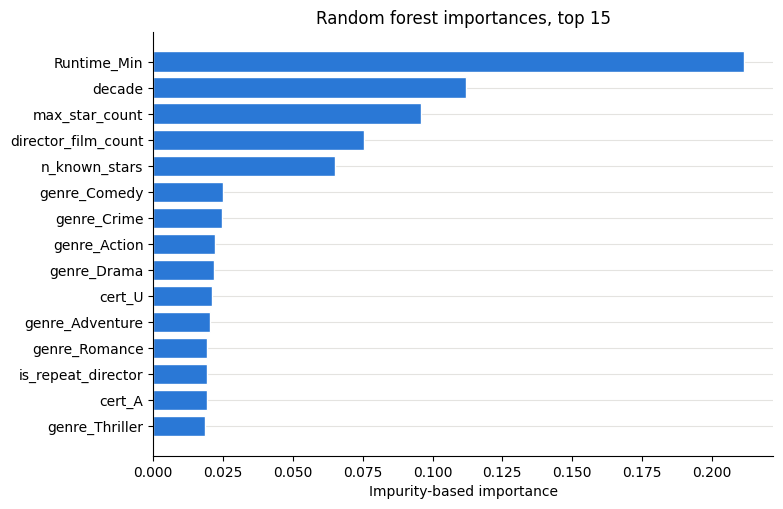

In [32]:
importances = pd.Series(forest.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(top15)), top15.values, color=BLUE, edgecolor="white")
ax.set_yticks(range(len(top15)), top15.index)
ax.grid(axis="x")
ax.set_title("Random forest importances, top 15")
ax.set_xlabel("Impurity-based importance")
plt.show()

The logistic coefficients are on scaled inputs, so their sizes are roughly comparable.

In [33]:
coefs = pd.Series(logreg.coef_[0], index=X_train_lr.columns).sort_values()
print("Most negative coefficients:")
print(coefs.head(5).round(3))
print("\nMost positive coefficients:")
print(coefs.tail(5).round(3))

Most negative coefficients:
cert_PG-13      -1.064
genre_Horror    -1.048
genre_Western   -0.723
genre_Family    -0.460
decade          -0.420
dtype: float64

Most positive coefficients:
cert_UA               0.332
is_repeat_director    0.409
genre_Animation       0.504
Runtime_Min           0.507
cert_Other            0.650
dtype: float64


The two views mostly agree with the EDA. Runtime is the forest's top feature (importance 0.211), with decade and the star and director counts filling the top five, and the logistic side pushes runtime positive too. Horror and PG-13 have the strongest negative coefficients, matching their weak class shares, and the individual genres matter little beyond that. The one surprise is Animation's positive coefficient. Its high rated share was near average, so I would not lean on it without more data.

### Does decade belong in the model?

I realized something about decade. Every film the client will actually score is from the current decade, so the feature is the same for all real candidates and cannot help rank them. The EDA also suggested the decade pattern is mostly survivorship, old films on a top 1000 list being the survivors of their era, so the learned trend is an artifact of the dataset, not a property of new projects. The forest still ranked decade second, so I want to know how much of the measured performance leans on it.

In [34]:
X_train_nd = X_train.drop(columns="decade")
X_test_nd = X_test.drop(columns="decade")

scale_cols_nd = ["Runtime_Min", "director_film_count", "max_star_count"]
scaler_nd = StandardScaler().fit(X_train_nd[scale_cols_nd])
X_train_nd_lr = X_train_nd.copy(); X_train_nd_lr[scale_cols_nd] = scaler_nd.transform(X_train_nd[scale_cols_nd])
X_test_nd_lr = X_test_nd.copy();  X_test_nd_lr[scale_cols_nd] = scaler_nd.transform(X_test_nd[scale_cols_nd])

logreg_nd = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_nd_lr, y_train)
forest_nd = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_nd, y_train)

def metric_row(model, X):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {"precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba)}

comparison = pd.DataFrame({
    "LR with decade": metric_row(logreg, X_test_lr),
    "LR no decade":   metric_row(logreg_nd, X_test_nd_lr),
    "RF with decade": metric_row(forest, X_test),
    "RF no decade":   metric_row(forest_nd, X_test_nd),
}).T.round(3)
print(comparison)

nd_proba = logreg_nd.predict_proba(X_test_nd_lr)[:, 1]
pred_040 = (nd_proba >= 0.40).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_040).ravel()
print(f"\nNo-decade LR at threshold 0.40: precision {precision_score(y_test, pred_040):.3f}"
      f" | recall {recall_score(y_test, pred_040):.3f} | hits caught {tp} of {tp + fn}"
      f" | false positives {fp}")

                precision  recall     F1  ROC-AUC
LR with decade      0.652   0.462  0.541    0.652
LR no decade        0.571   0.430  0.491    0.650
RF with decade      0.614   0.462  0.528    0.628
RF no decade        0.591   0.419  0.491    0.601

No-decade LR at threshold 0.40: precision 0.565 | recall 0.753 | hits caught 70 of 93 | false positives 54


For the logistic model, ranking ability didn't change much. ROC-AUC is 0.652 with decade and 0.650 without. The default-threshold numbers shift some (precision 0.652 to 0.571, recall 0.462 to 0.430), but I can retune the threshold anyway. The forest leans harder on decade, dropping from 0.628 to 0.601, which fits its importance ranking and smells like era effects. Since the logistic model loses essentially nothing, the final model drops decade. A feature that is identical for every real candidate is worthless in use, whatever it added on historical data. The with-decade numbers stay above as the benchmark.

So the final setup is logistic regression without decade, using runtime, the genre and certificate columns, and the director and cast counts, unweighted, threshold 0.40. At that threshold it catches 70 of the 93 high rated test films, recall 0.753 at precision 0.565, with 54 false positives. Recall is actually a bit better than with decade included.

The model has real signal, but it is modest, an ROC-AUC of 0.650 against a base rate of 46.5 percent. As a strict yes or no answer it would disappoint. As a ranking tool, the use we agreed on, it works. Stronger projects rise toward the top. With decade dropped and the threshold at 0.40 it catches 70 of the 93 likely hits in the test set, recall 0.75, matching the client's priority of not missing hits. The cost is 54 backed films that fall short.

## The funding priority list

The metrics above are for judging the model. In practice the studio would score a slate of candidates and read them top down as a funding priority list. Here are the 15 test films the final model is most confident about, ordered by predicted probability of a high rating.

In [35]:
shortlist = pd.DataFrame({
    "Series_Title": test_df["Series_Title"],
    "predicted_probability": nd_proba.round(3),
    "actual": np.where(y_test, "high rated", "below 8.0"),
}).sort_values("predicted_probability", ascending=False)

print(shortlist.head(15).to_string(index=False))
print("\nActual hits in the top 15:", (shortlist.head(15)["actual"] == "high rated").sum())

                Series_Title  predicted_probability     actual
                   Kagemusha                  0.816 high rated
       Judgment at Nuremberg                  0.811 high rated
              Doctor Zhivago                  0.798 high rated
                       Ikiru                  0.763 high rated
                     Titanic                  0.743  below 8.0
           The Hateful Eight                  0.739  below 8.0
          The Great Dictator                  0.735 high rated
       From Here to Eternity                  0.727  below 8.0
                Pulp Fiction                  0.727 high rated
         Munna Bhai M.B.B.S.                  0.709 high rated
                 L'avventura                  0.708  below 8.0
         Saving Private Ryan                  0.696 high rated
                    Scarface                  0.695 high rated
Mr. Smith Goes to Washington                  0.691 high rated
              Kelly's Heroes                  0.685  be

Ten of the 15 are actual hits, against a base rate of 46.5 percent, so the top of the ranking is clearly richer in strong films than a random draw, though Titanic and The Hateful Eight sit high and fell short of 8.0. However, the actual outcome column only exists because these films are released. In real use the list would end at the probability column; the outcome is shown here so the ranking's quality is visible.

## Assumptions log

The proposal's dataset is IMDb's top 1000, which contains no poorly received films. I flagged this to the client, who approved proceeding and also offered an alternative dataset with a full spread of ratings. I declined because the offer came mid-EDA and switching meant redoing all the cleaning and EDA. The limitation stays documented and the model is framed as ranking within an already strong field.

On error costs, the client said missing a potential hit is worse than funding a film that underperforms. Evaluation therefore prioritizes recall on the high rated class and accepts some false positives.

On scope, the client floated adding film budgets. The dataset has no budget column, so this is out of scope, and the client's own constraints note budget is absent.

Meta_score, No_of_Votes, and Gross are excluded as inputs because they do not exist during pre-production. Confirmed with the client.

## Limitations

The biggest limitation is selection. The dataset is IMDb's top 1000, so the model has never seen a poorly received film. It learned to tell good from exceptional, and scores for genuinely weak projects would be unreliable.

Certificate also leaks era. Passed and Approved certificates only exist for films from before 1968, so the column partly encodes when a film was made. Dropping decade reduced era effects but did not remove them.

There is no budget, marketing spend, or release timing in the data, all of which plausibly matter to a funding decision. The model ranks on film characteristics alone.

The director and cast counts only cover appearances within this dataset. A director with one film here may have many outside the top 1000, so first timers and the unrecognized look the same.

The client offered a fuller dataset covering the whole rating spread. Rebuilding on it would let the model learn what separates weak films from strong ones, closer to the client's real question, and it is the first thing I would do with another iteration.

## Executive summary

Prepared for the Director of Film Development, Silver Screen Studios.

This tool ranks candidate film projects by how likely they are to be strongly received by audiences. It scores each project using only what is known before production begins: genre, runtime, age certificate, and how often the attached director and lead cast appear in a benchmark list of well regarded films. Higher scoring projects most resemble past audience favorites.

At the setting we recommend, the tool catches about three of every four projects that would go on to be strongly received. The cost of casting that wide a net is that roughly half of the projects it flags will fall short of the bar. It is a prioritization aid. Use it to order the slate and focus attention, alongside market research and your team's judgment, not as a green light machine.

There are two cautions are worth keeping in mind. The tool was built from a list of films that were already successful, so it compares candidates against a strong field. It does not detect failures and a weak project may not receive the low score it deserves. It also knows nothing about budget or marketing, which shape outcomes in ways it cannot see.

## Links

Video presentation: https://youtu.be/tX0-Cwpsq24